In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [2]:
skolky_body = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")
obce_polygony = gpd.read_file("geometrie/obce_slbd.geojson").to_crs(5514)
obce_polygony = obce_polygony[["geometry","celkem", "Kód_obce"]]

In [3]:
pocet_skolek = gpd.sjoin(skolky_body, obce_polygony, how="inner", predicate="within")
obce_polygony["count"] = pocet_skolek.groupby("index_right").size()
#obce_polygony["count"] = obce_polygony["count"].fillna(0)



In [4]:
obce_skolky= gpd.sjoin(skolky_body,obce_polygony)
#obce_skolky = gpd.sjoin(obce_polygony,skolky_body)

In [5]:
bins = [0, 3000,float('inf')]
labels = [1, 2]

obce_skolky["size_category"] = pd.cut(
    obce_skolky["celkem"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)


In [6]:
obce_venkov = obce_skolky[obce_skolky["size_category"]==1]
obce_mesto = obce_skolky[obce_skolky["size_category"]==2]


In [7]:
obce_venkov.to_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_venkov.parquet")
obce_mesto.to_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_mesto.parquet")

In [8]:
avg_price = obce_skolky.groupby('Kód_obce').agg({
    'monthly_fe': 'mean',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce','monthly_fe']}
})
print(avg.mean(axis=0).round())
avg = avg_price.pivot_table(
    values="monthly_fe",
    index="Kraj",
    columns="size_category",
    aggfunc="mean"
).round()
avg



NameError: name 'avg' is not defined

In [ ]:
std_price = obce_skolky.groupby('Kód_obce').agg({
    'monthly_fe': 'std',
    **{col: 'first' for col in obce_skolky.columns if col not in ['Kód_obce','monthly_fe']}
})

std = std_price.pivot_table(
    values="monthly_fe",
    index="Kraj",
    columns="size_category",
    aggfunc="mean"
).round()
print(std.mean(axis=0).round())
std


size_category
1    83.0
2    49.0
dtype: float64


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_3892/2876588755.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  std = std_price.pivot_table(


size_category,1,2
Kraj,,
Hlavní město Praha,NaN,234.0
Jihomoravský kraj,NaN,24.0
Jihočeský kraj,NaN,7.0
Karlovarský kraj,71.0,49.0
Kraj Vysočina,NaN,47.0
Královéhradecký kraj,NaN,64.0
Liberecký kraj,0.0,65.0
Moravskoslezský kraj,NaN,47.0
Olomoucký kraj,NaN,49.0


In [ ]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]

In [ ]:
size_counts_total = obce_skolky.groupby("size_category").size()
size_counts = fee.groupby('size_category').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('size_category')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('size_category')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('size_category')['monthly_fe'].std()

table.round()

/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_3892/2672294070.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts_total = obce_skolky.groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_3892/2672294070.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts = fee.groupby('size_category').size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_3892/2672294070.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or

,total_count,count,percentage,average_fee,median_fee,std_fee
size_category,,,,,,
1,2951,996,34.0,453.0,400.0,238.0
2,1837,816,44.0,764.0,700.0,307.0


In [ ]:
tables_by_orp = {}

for orp, df_orp in obce_skolky.groupby("Název_ORP"):

    size_counts_total = df_orp.groupby("size_category").size()
    size_counts = df_orp[df_orp["monthly_fe"].notna()].groupby("size_category").size()

    table = pd.DataFrame({
        "total_count": size_counts_total,
        "count": size_counts
    })

    table["percentage"] = table["count"] / table["total_count"] * 100
    table["average_fee"] = df_orp.groupby("size_category")["monthly_fe"].mean()
    table["median_fee"] = df_orp.groupby("size_category")["monthly_fe"].median()
    table["std_fee"] = df_orp.groupby("size_category")["monthly_fe"].std()

    tables_by_orp[orp] = table.round()


/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_3892/198270040.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts_total = df_orp.groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_3892/198270040.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_counts = df_orp[df_orp["monthly_fe"].notna()].groupby("size_category").size()
/var/folders/gl/6m73nrcs3yqd6q9dyxldg7th0000gn/T/ipykernel_3892/198270040.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to 

In [ ]:
tables_by_orp["Tachov"]


,total_count,count,percentage,average_fee,median_fee,std_fee
size_category,,,,,,
1,12,6,50.0,375.0,375.0,133.0
2,7,5,71.0,1000.0,1000.0,0.0


In [ ]:
orp_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/ORP.geojson")
orp_polygony["naz_orp_p"] = orp_polygony["naz_orp_p"].replace({"Praha": "Hlavní město Praha"})

In [ ]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]
orp_counts_total = skolky_body.groupby("Název_ORP").size()
orp_counts = fee.groupby('Název_ORP').size()
table = pd.DataFrame({"total_count": orp_counts_total, "count": orp_counts})
table['percentage'] = (table['count'] / table['total_count'] * 100).round()
table['average_fee'] = skolky_body.groupby('Název_ORP')['monthly_fe'].mean().round()
table['median_fee'] = skolky_body.groupby('Název_ORP')['monthly_fe'].median().round()

table['std_fee'] = skolky_body.groupby('Název_ORP')['monthly_fe'].std().round()

table.sort_values('average_fee', ascending=False).head(20)

,total_count,count,percentage,average_fee,median_fee,std_fee
Název_ORP,,,,,,
Říčany,41,26,63.0,1220.0,1250.0,302.0
Hlavní město Praha,299,166,56.0,1192.0,1200.0,234.0
Brandýs nad Labem-Stará Boleslav,52,31,60.0,1066.0,1000.0,355.0
Černošice,69,18,26.0,872.0,900.0,219.0
Brno,138,64,46.0,849.0,900.0,156.0
Český Brod,14,4,29.0,838.0,850.0,149.0
Holice,11,4,36.0,750.0,825.0,168.0
Liberec,56,16,29.0,739.0,813.0,180.0
Turnov,22,13,59.0,738.0,800.0,284.0


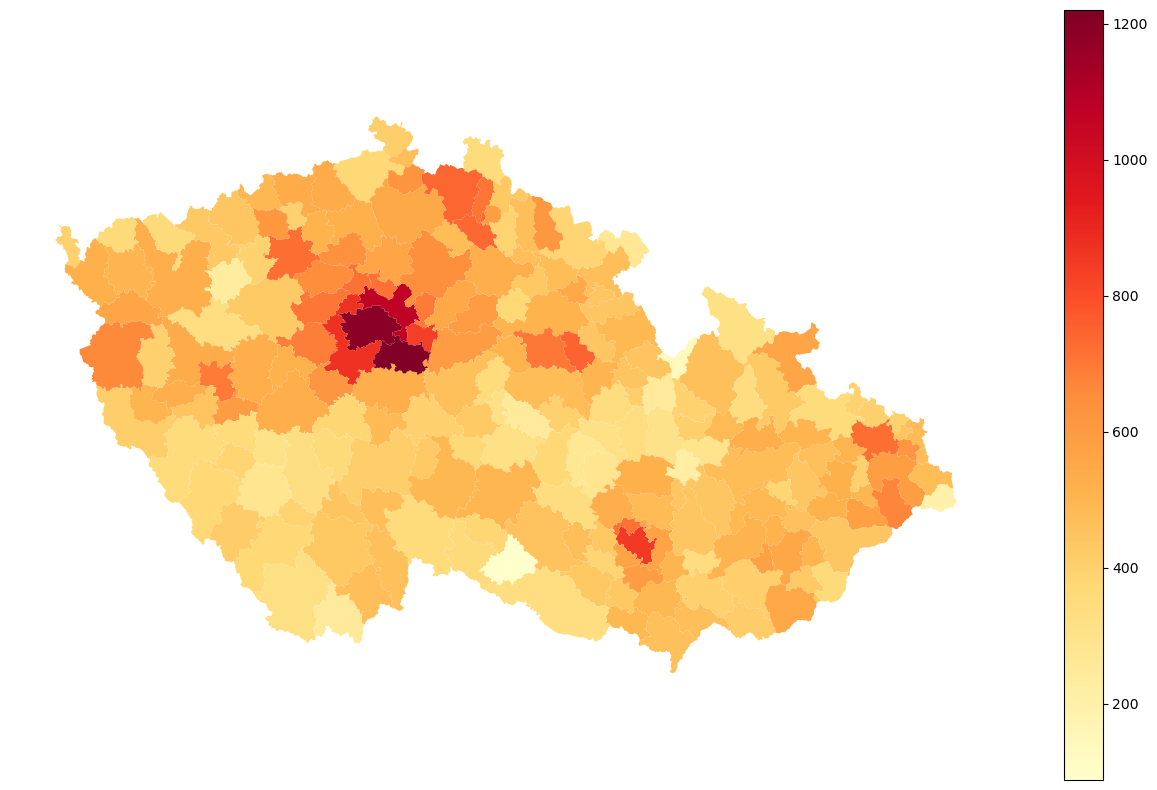

In [ ]:
orp = orp_polygony.merge(table, left_on ="naz_orp_p", right_index=True)
orp.plot("average_fee", figsize=(16,10),legend=True,cmap="YlOrRd").set_axis_off()

In [ ]:
tables_by_size = {}

for size_cat in obce_skolky["size_category"].unique():
    sub = obce_skolky[obce_skolky["size_category"] == size_cat]
    fee = sub[sub["monthly_fe"].notna()]

    table = pd.DataFrame({
        "total_count": sub.groupby("Název_ORP").size(),
        "count": fee.groupby("Název_ORP").size()
    })

    table["percentage"] = (table["count"] / table["total_count"] * 100).round()
    table["average_fee"] = sub.groupby("Název_ORP")["monthly_fe"].mean().round()
    table["median_fee"] = sub.groupby("Název_ORP")["monthly_fe"].median().round()
    table["std_fee"] = sub.groupby("Název_ORP")["monthly_fe"].std().round()

    tables_by_size[size_cat] = table.sort_values("percentage", ascending=True)


In [ ]:
tables_by_size[2].sort_values("count")

,total_count,count,percentage,average_fee,median_fee,std_fee
Název_ORP,,,,,,
Strakonice,9,1.0,11.0,430.0,430.0,NaN
Horšovský Týn,2,1.0,50.0,500.0,500.0,NaN
Mikulov,2,1.0,50.0,600.0,600.0,NaN
Kuřim,2,1.0,50.0,950.0,950.0,NaN
Náměšť nad Oslavou,2,1.0,50.0,500.0,500.0,NaN
...,...,...,...,...,...,...
Svitavy,6,NaN,NaN,NaN,NaN,NaN
Tanvald,2,NaN,NaN,NaN,NaN,NaN
Trutnov,2,NaN,NaN,NaN,NaN,NaN


In [ ]:
tables_by_size[1]["percentage"].mean()

np.float64(36.865671641791046)

In [ ]:
tables_by_size[2]["percentage"].mean()

np.float64(55.798882681564244)

In [ ]:
mesto = orp_polygony.merge(tables_by_size[2], left_on ="naz_orp_p", right_index=True)
venkov = orp_polygony.merge(tables_by_size[1], left_on ="naz_orp_p", right_index=True)


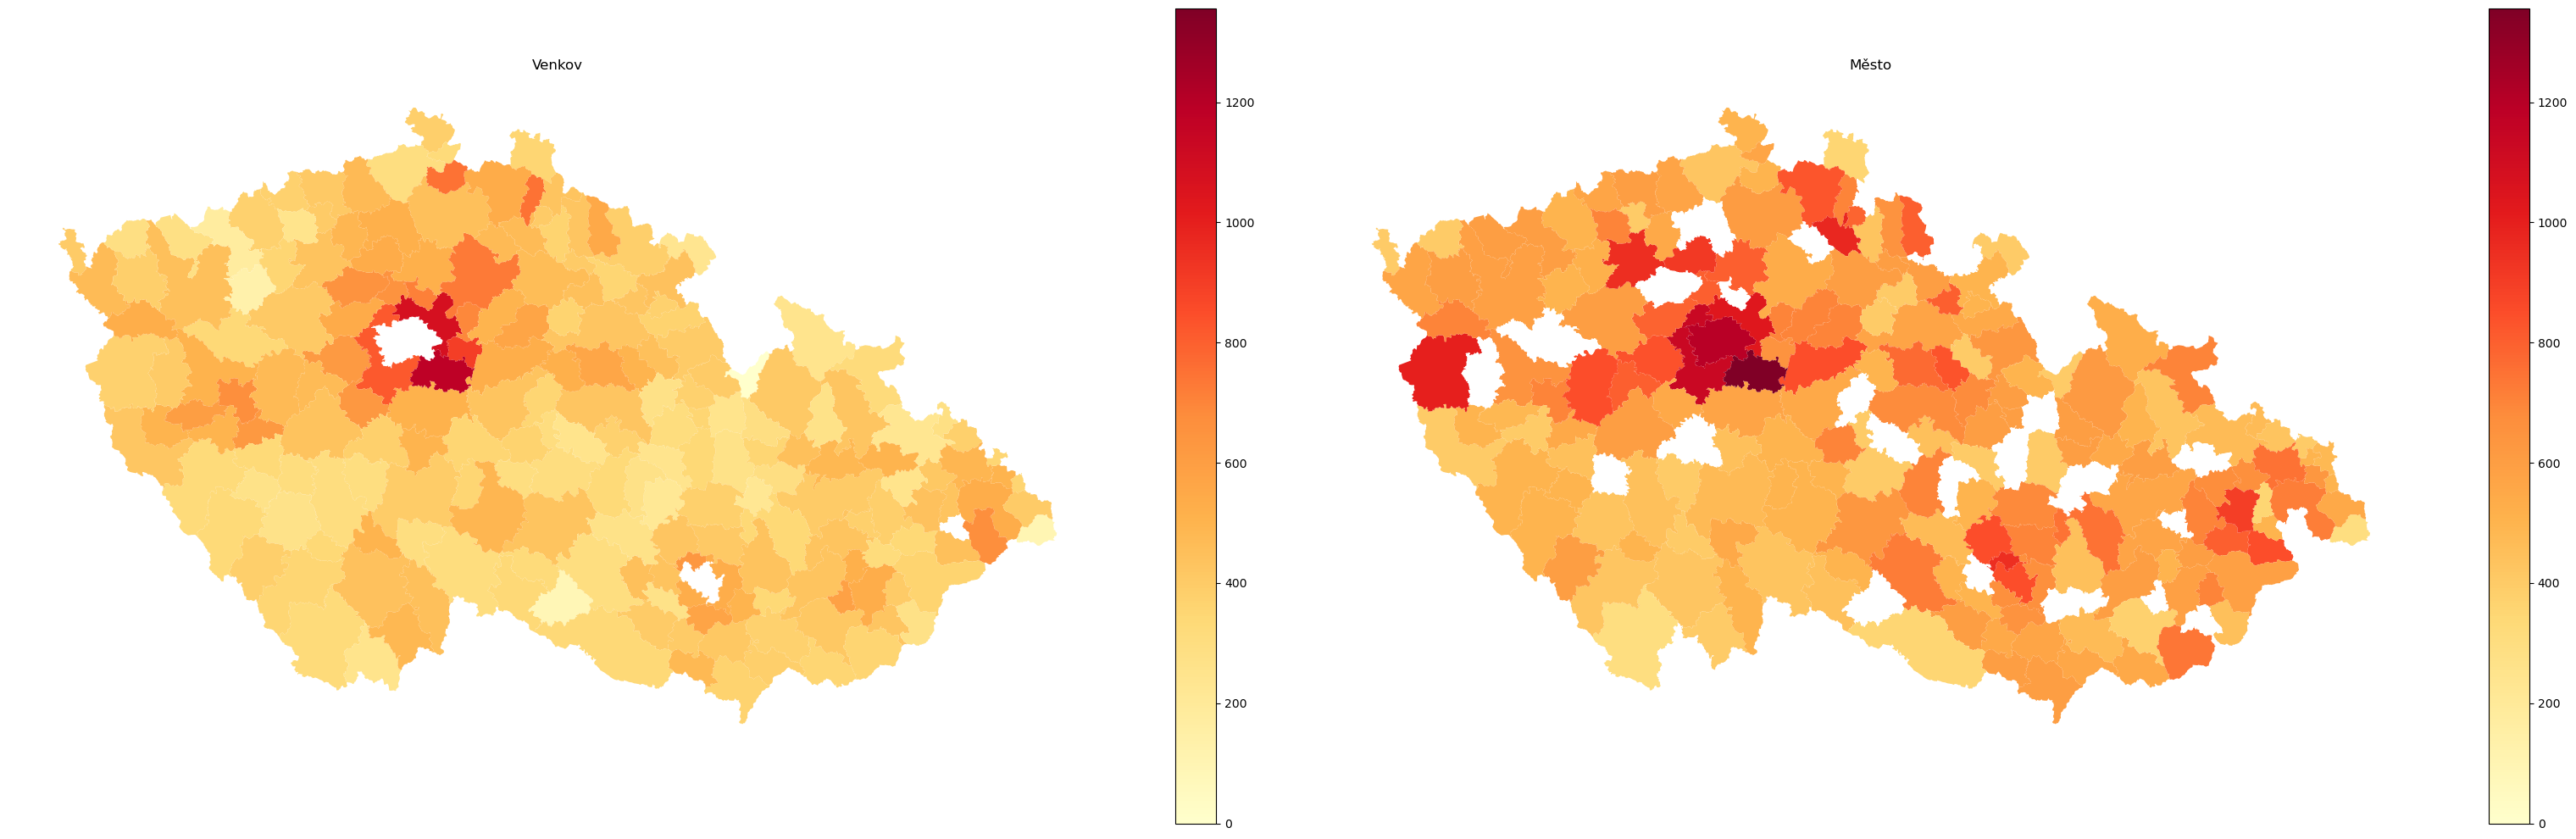

In [ ]:
# find the global min and max for average_fee
vmin = min(venkov["average_fee"].min(), mesto["average_fee"].min())
vmax = max(venkov["average_fee"].max(), mesto["average_fee"].max())

fig, axes = plt.subplots(1, 2, figsize=(32, 10))

# plot venkov
venkov.plot(
    column="average_fee",
    ax=axes[0],
    legend=True,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    missing_kwds={"color": "white"}
)
axes[0].set_title("Venkov")
axes[0].set_axis_off()

# plot mesto
mesto.plot(
    column="average_fee",
    ax=axes[1],
    legend=True,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    missing_kwds={"color": "white"}
)
axes[1].set_title("Město")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


In [ ]:
kraje_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/kraje.geojson")

In [ ]:
tables_by_size = {}

for size_cat in obce_skolky["size_category"].unique():
    sub = obce_skolky[obce_skolky["size_category"] == size_cat]
    fee = sub[sub["monthly_fe"].notna()]

    table = pd.DataFrame({
        "total_count": sub.groupby("Kraj").size(),
        "count": fee.groupby("Kraj").size()
    })

    table["percentage"] = (table["count"] / table["total_count"] * 100).round()
    table["average_fee"] = sub.groupby("Kraj")["monthly_fe"].mean().round()
    table["median_fee"] = sub.groupby("Kraj")["monthly_fe"].median().round()
    table["std_fee"] = sub.groupby("Kraj")["monthly_fe"].std().round()

    tables_by_size[size_cat] = table.sort_values("percentage", ascending=True)


In [ ]:
tables_by_size[1]

,total_count,count,percentage,average_fee,median_fee,std_fee
Kraj,,,,,,
Zlínský kraj,203,55,27.0,416.0,400.0,135.0
Kraj Vysočina,236,65,28.0,319.0,300.0,128.0
Liberecký kraj,117,33,28.0,470.0,400.0,154.0
Královéhradecký kraj,208,60,29.0,411.0,400.0,113.0
Jihomoravský kraj,389,116,30.0,420.0,400.0,145.0
Pardubický kraj,209,69,33.0,363.0,350.0,160.0
Plzeňský kraj,172,58,34.0,430.0,400.0,158.0
Karlovarský kraj,66,23,35.0,408.0,400.0,131.0
Olomoucký kraj,263,98,37.0,350.0,385.0,189.0


In [ ]:
tables_by_size[2]

,total_count,count,percentage,average_fee,median_fee,std_fee
Kraj,,,,,,
Jihočeský kraj,96,26,27.0,445.0,440.0,61.0
Zlínský kraj,92,30,33.0,624.0,600.0,147.0
Středočeský kraj,189,73,39.0,800.0,800.0,294.0
Liberecký kraj,96,38,40.0,736.0,760.0,211.0
Olomoucký kraj,86,36,42.0,616.0,600.0,153.0
Pardubický kraj,99,42,42.0,647.0,650.0,170.0
Ústecký kraj,151,64,42.0,608.0,600.0,173.0
Karlovarský kraj,51,22,43.0,553.0,600.0,124.0
Jihomoravský kraj,239,104,44.0,747.0,800.0,210.0


In [ ]:
mesto = kraje_polygony.merge(tables_by_size[2], left_on ="NAZEV", right_index=True)
venkov = kraje_polygony.merge(tables_by_size[1], left_on ="NAZEV", right_index=True)


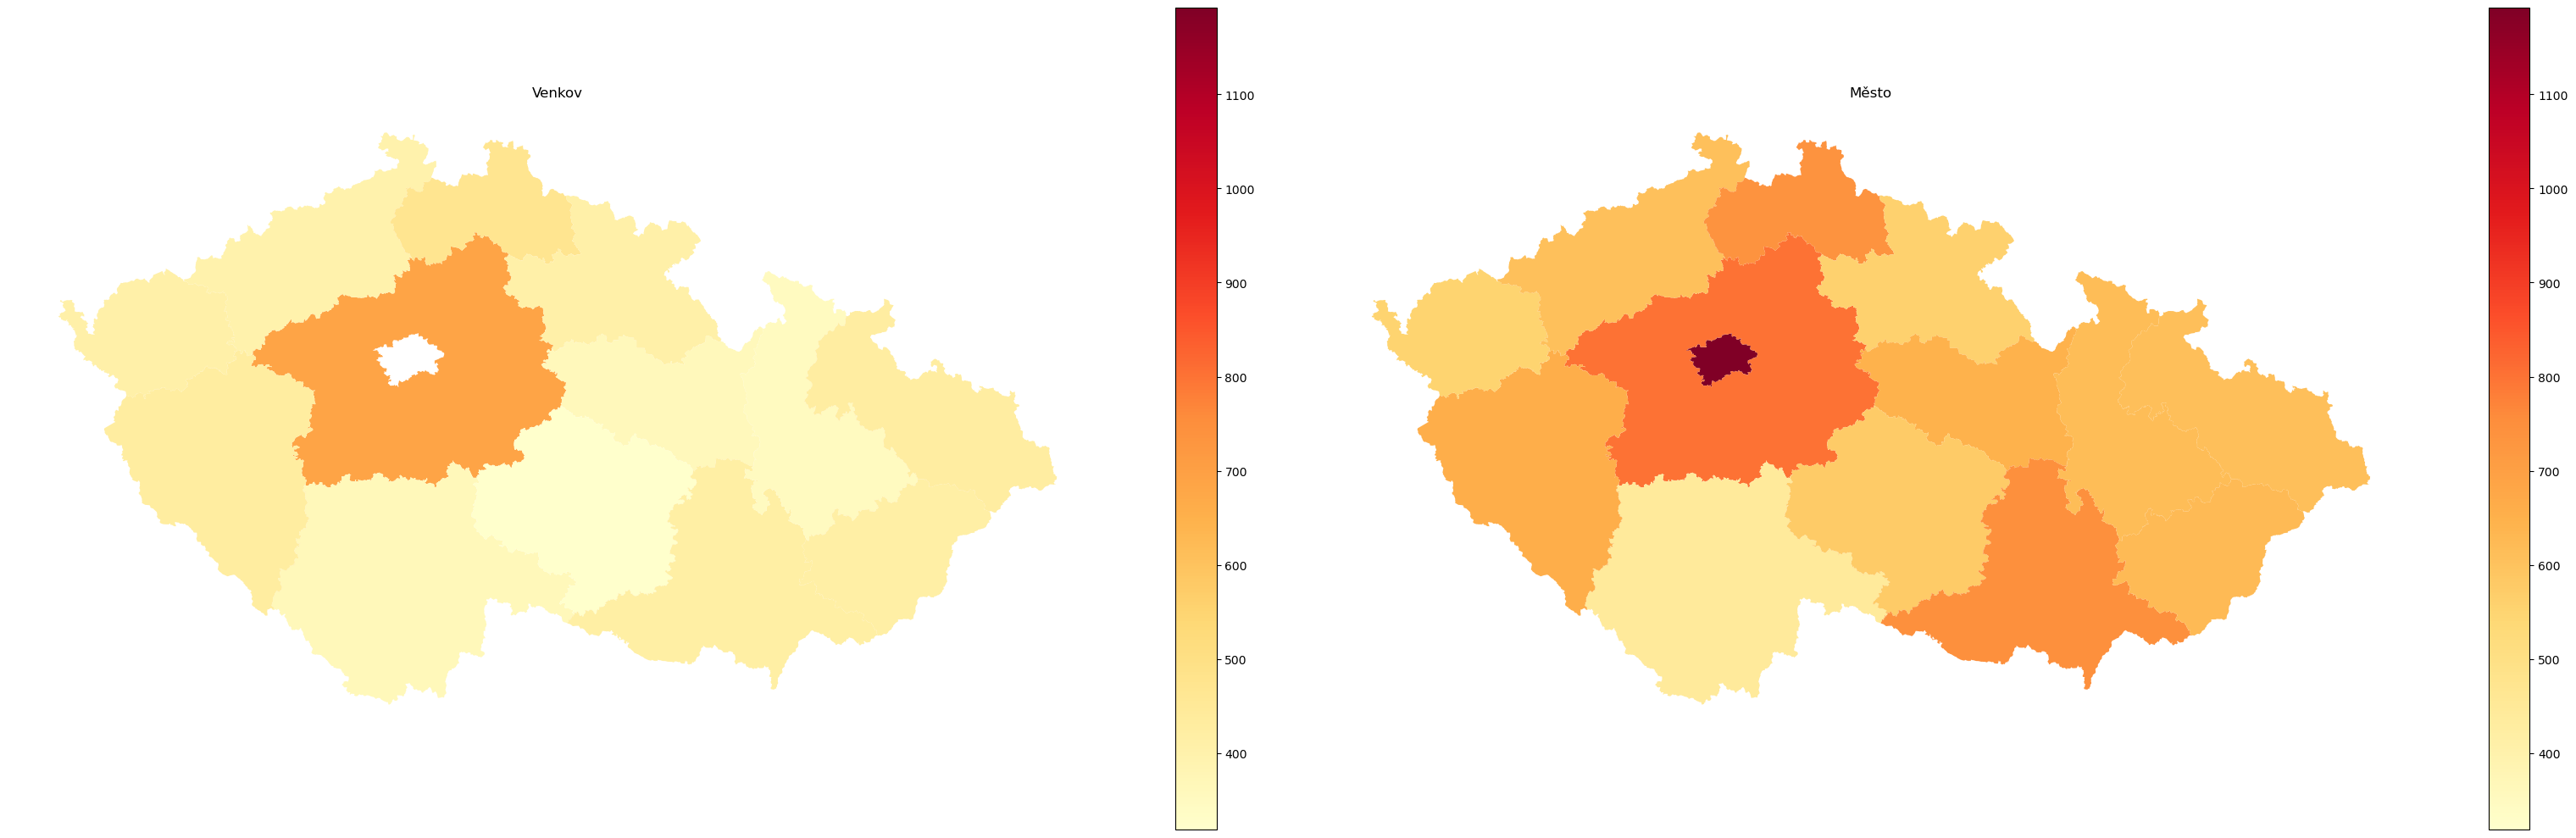

In [ ]:
# find the global min and max for average_fee
vmin = min(venkov["average_fee"].min(), mesto["average_fee"].min())
vmax = max(venkov["average_fee"].max(), mesto["average_fee"].max())

fig, axes = plt.subplots(1, 2, figsize=(32, 10))

# plot venkov
venkov.plot(
    column="average_fee",
    ax=axes[0],
    legend=True,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    missing_kwds={"color": "white"}
)
axes[0].set_title("Venkov")
axes[0].set_axis_off()

# plot mesto
mesto.plot(
    column="average_fee",
    ax=axes[1],
    legend=True,
    cmap="YlOrRd",
    vmin=vmin,
    vmax=vmax,
    missing_kwds={"color": "white"}
)
axes[1].set_title("Město")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()
